# Proyecto 06 — Modelo de Expected Goals (xG)

Construimos un modelo predictivo de xG **desde cero** usando los datos de tiros de StatsBomb (Premier League 2015/16).  
Comparamos Logistic Regression (baseline) contra Gradient Boosting y evaluamos con AUC-ROC, Log Loss y curva de calibración.

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'scikit-learn'])


CompletedProcess(args=['c:\\Users\\hcard\\miniconda3\\envs\\futbol_analytics\\python.exe', '-m', 'pip', 'install', 'scikit-learn'], returncode=0)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mplsoccer import Pitch
from statsbombpy import sb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, log_loss, roc_curve, brier_score_loss
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

BG     = '#0d1117'
COLOR  = '#58a6ff'
ACCENT = '#f78166'
GREEN  = '#3fb950'
GOLD   = '#FFD700'

import os
os.makedirs('graficos', exist_ok=True)
print('Setup completo')

Setup completo


## 1. Carga de datos — todos los tiros de la PL 2015/16

In [3]:
matches = sb.matches(competition_id=2, season_id=27)
print(f'Partidos cargados: {len(matches)}')

Partidos cargados: 380


In [4]:
all_shots = []
match_ids = matches['match_id'].tolist()

for i, mid in enumerate(match_ids):
    try:
        events = sb.events(match_id=mid)
        shots = events[events['type'] == 'Shot'].copy()
        if len(shots) > 0:
            shots['match_id'] = mid
            all_shots.append(shots)
    except Exception as e:
        print(f'Error en match {mid}: {e}')
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/380 partidos procesados...')

shots_df = pd.concat(all_shots, ignore_index=True)
print(f'\nTotal tiros: {len(shots_df):,}')
print(f'Goles: {(shots_df["shot_outcome"] == "Goal").sum()}')

  50/380 partidos procesados...
  100/380 partidos procesados...
  150/380 partidos procesados...
  200/380 partidos procesados...
  250/380 partidos procesados...
  300/380 partidos procesados...
  350/380 partidos procesados...

Total tiros: 9,908
Goles: 988


## 2. Feature Engineering

In [5]:
def compute_distance(x, y):
    """Distancia euclidiana al centro del arco (120, 40)"""
    return np.sqrt((120 - x)**2 + (40 - y)**2)

def compute_angle(x, y):
    """Ángulo subtendido por los postes (120,36) y (120,44) desde la posición del tiro"""
    a = np.sqrt((120 - x)**2 + (44 - y)**2)
    b = np.sqrt((120 - x)**2 + (36 - y)**2)
    c = 8.0  # ancho del arco
    cos_angle = (a**2 + b**2 - c**2) / (2 * a * b)
    return np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))

def count_defenders_freeze(row):
    """Cuenta defensores entre el tirador y el arco usando freeze frame"""
    ff = row.get('shot_freeze_frame', None)
    if not isinstance(ff, list) or len(ff) == 0:
        return 0
    x_shot = row['x']
    count = 0
    for p in ff:
        if not p.get('teammate', True) and isinstance(p.get('location'), list):
            if p['location'][0] > x_shot:
                count += 1
    return count

# Coordenadas
shots_df['x'] = shots_df['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else np.nan)
shots_df['y'] = shots_df['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else np.nan)

# Features geométricas
shots_df['distance'] = shots_df.apply(lambda r: compute_distance(r['x'], r['y']), axis=1)
shots_df['angle']    = shots_df.apply(lambda r: compute_angle(r['x'], r['y']), axis=1)

# Target
shots_df['goal'] = (shots_df['shot_outcome'] == 'Goal').astype(int)

# Features categóricas binarias
shots_df['is_head']             = (shots_df['shot_body_part'] == 'Head').astype(int)
shots_df['is_open_play']        = shots_df['play_pattern'].apply(lambda p: 1 if p == 'Regular Play' else 0)
shots_df['under_pressure']      = shots_df['under_pressure'].fillna(False).astype(int)
shots_df['one_on_one']          = shots_df['shot_one_on_one'].fillna(False).astype(int)
shots_df['is_normal_technique'] = shots_df['shot_technique'].apply(lambda t: 1 if t == 'Normal' else 0)
shots_df['defenders_freeze']    = shots_df.apply(count_defenders_freeze, axis=1)

FEATURES = ['distance', 'angle', 'is_head', 'is_open_play',
            'under_pressure', 'one_on_one', 'is_normal_technique', 'defenders_freeze']

print('Features creadas:')
print(shots_df[FEATURES + ['goal']].describe().round(3))

Features creadas:
       distance     angle   is_head  is_open_play  under_pressure  one_on_one  \
count  9908.000  9908.000  9908.000      9908.000        9908.000    9908.000   
mean     19.072    25.385     0.162         0.335           0.216       0.047   
std       8.291    15.726     0.369         0.472           0.411       0.211   
min       0.922     0.061     0.000         0.000           0.000       0.000   
25%      12.126    15.305     0.000         0.000           0.000       0.000   
50%      18.792    19.546     0.000         0.000           0.000       0.000   
75%      25.340    30.929     0.000         1.000           0.000       0.000   
max      86.137   159.714     1.000         1.000           1.000       1.000   

       is_normal_technique  defenders_freeze    goal  
count             9908.000           9908.00  9908.0  
mean                 0.782              5.54     0.1  
std                  0.413              2.88     0.3  
min                  0.000      

## 3. Exploración del dataset

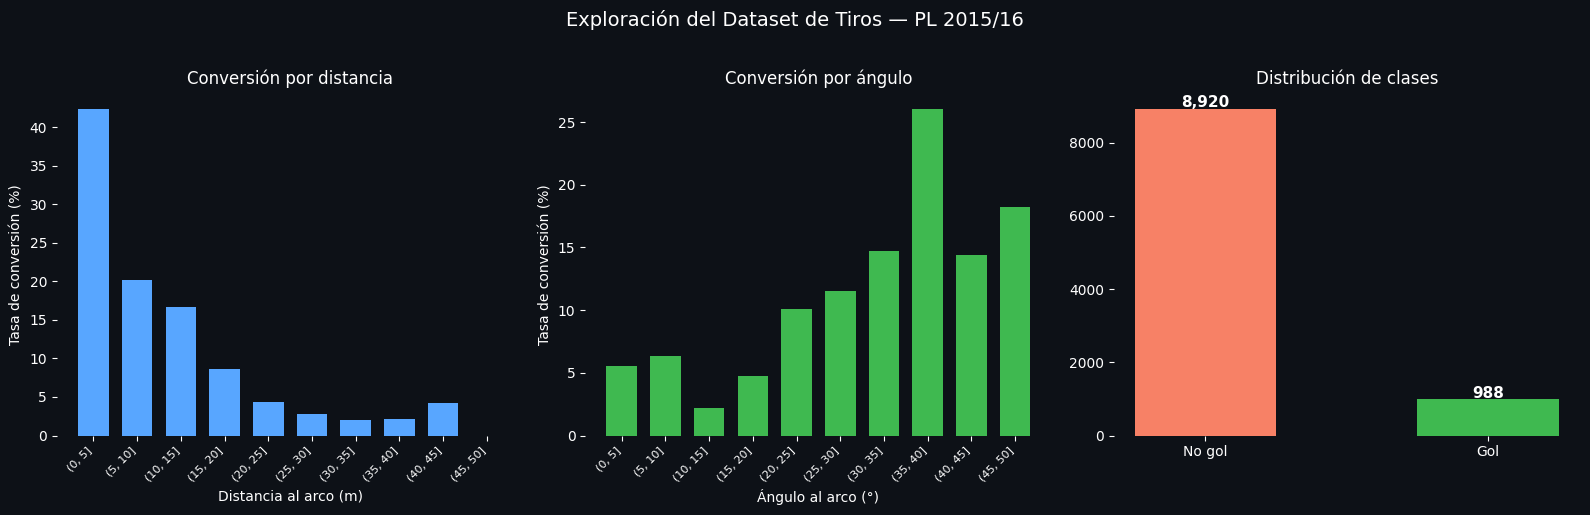

Guardado: p06_01_dataset_overview.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)

# Conversión por distancia
shots_df['dist_bin'] = pd.cut(shots_df['distance'], bins=range(0, 55, 5))
conv_d = shots_df.groupby('dist_bin', observed=True)['goal'].mean() * 100

ax = axes[0]
ax.set_facecolor(BG)
ax.bar(range(len(conv_d)), conv_d.values, color=COLOR, width=0.7, edgecolor='none')
ax.set_xticks(range(len(conv_d)))
ax.set_xticklabels([str(b) for b in conv_d.index], rotation=45, ha='right', fontsize=8, color='white')
ax.set_xlabel('Distancia al arco (m)', color='white')
ax.set_ylabel('Tasa de conversión (%)', color='white')
ax.set_title('Conversión por distancia', color='white', fontsize=12)
ax.tick_params(colors='white')
ax.spines[:].set_visible(False)

# Conversión por ángulo
shots_df['angle_bin'] = pd.cut(shots_df['angle'], bins=range(0, 55, 5))
conv_a = shots_df.groupby('angle_bin', observed=True)['goal'].mean() * 100

ax = axes[1]
ax.set_facecolor(BG)
ax.bar(range(len(conv_a)), conv_a.values, color=GREEN, width=0.7, edgecolor='none')
ax.set_xticks(range(len(conv_a)))
ax.set_xticklabels([str(b) for b in conv_a.index], rotation=45, ha='right', fontsize=8, color='white')
ax.set_xlabel('Ángulo al arco (°)', color='white')
ax.set_ylabel('Tasa de conversión (%)', color='white')
ax.set_title('Conversión por ángulo', color='white', fontsize=12)
ax.tick_params(colors='white')
ax.spines[:].set_visible(False)

# Balance de clases
ax = axes[2]
ax.set_facecolor(BG)
counts = shots_df['goal'].value_counts()
bars = ax.bar(['No gol', 'Gol'], [counts[0], counts.get(1, 0)], color=[ACCENT, GREEN], width=0.5)
for bar, val in zip(bars, [counts[0], counts.get(1, 0)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', color='white', fontsize=11, fontweight='bold')
ax.set_title('Distribución de clases', color='white', fontsize=12)
ax.tick_params(colors='white')
ax.spines[:].set_visible(False)

fig.suptitle('Exploración del Dataset de Tiros — PL 2015/16', color='white', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('graficos/p06_01_dataset_overview.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Guardado: p06_01_dataset_overview.png')

## 4. Entrenamiento de modelos

In [7]:
clean = shots_df[FEATURES + ['goal']].dropna()
X = clean[FEATURES].values
y = clean['goal'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,} tiros | Test: {len(X_test):,} tiros')
print(f'Tasa de gol — train: {y_train.mean():.3f} | test: {y_test.mean():.3f}')

# Logistic Regression (baseline)
lr = LogisticRegression(max_iter=1000, C=1.0)
lr.fit(X_train, y_train)
lr_probs = lr.predict_proba(X_test)[:, 1]

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
gb_probs = gb.predict_proba(X_test)[:, 1]

print('\nResultados en test set:')
print(f'  Logistic Regression — AUC: {roc_auc_score(y_test, lr_probs):.4f}  Log Loss: {log_loss(y_test, lr_probs):.4f}')
print(f'  Gradient Boosting   — AUC: {roc_auc_score(y_test, gb_probs):.4f}  Log Loss: {log_loss(y_test, gb_probs):.4f}')

Train: 7,926 tiros | Test: 1,982 tiros
Tasa de gol — train: 0.100 | test: 0.100

Resultados en test set:
  Logistic Regression — AUC: 0.7664  Log Loss: 0.2784
  Gradient Boosting   — AUC: 0.7800  Log Loss: 0.2720


## 5. Curva ROC

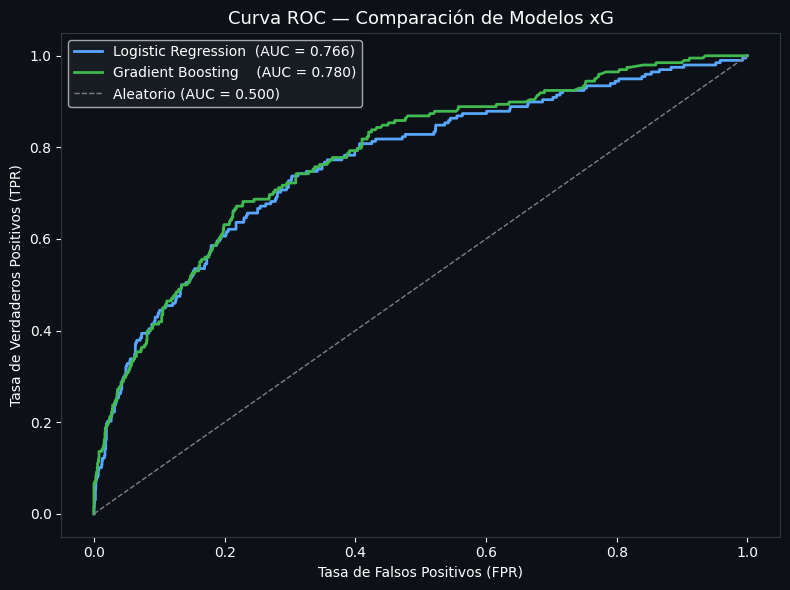

Guardado: p06_02_roc_curves.png


In [8]:
fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
ax.set_facecolor(BG)

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_probs)
auc_lr = roc_auc_score(y_test, lr_probs)
auc_gb = roc_auc_score(y_test, gb_probs)

ax.plot(fpr_lr, tpr_lr, color=COLOR,  lw=2, label=f'Logistic Regression  (AUC = {auc_lr:.3f})')
ax.plot(fpr_gb, tpr_gb, color=GREEN,  lw=2, label=f'Gradient Boosting    (AUC = {auc_gb:.3f})')
ax.plot([0, 1],  [0, 1], '--', color='gray', lw=1, label='Aleatorio (AUC = 0.500)')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', color='white')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', color='white')
ax.set_title('Curva ROC — Comparación de Modelos xG', color='white', fontsize=13)
ax.legend(facecolor='#1c2128', labelcolor='white', framealpha=0.8)
ax.tick_params(colors='white')
ax.spines[:].set_color('#30363d')

plt.tight_layout()
plt.savefig('graficos/p06_02_roc_curves.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Guardado: p06_02_roc_curves.png')

## 6. Curva de calibración

Un buen modelo de xG no solo debe discriminar (AUC alto) sino también estar bien **calibrado**: si el modelo dice 0.20 xG, debería convertirse el 20% de las veces.

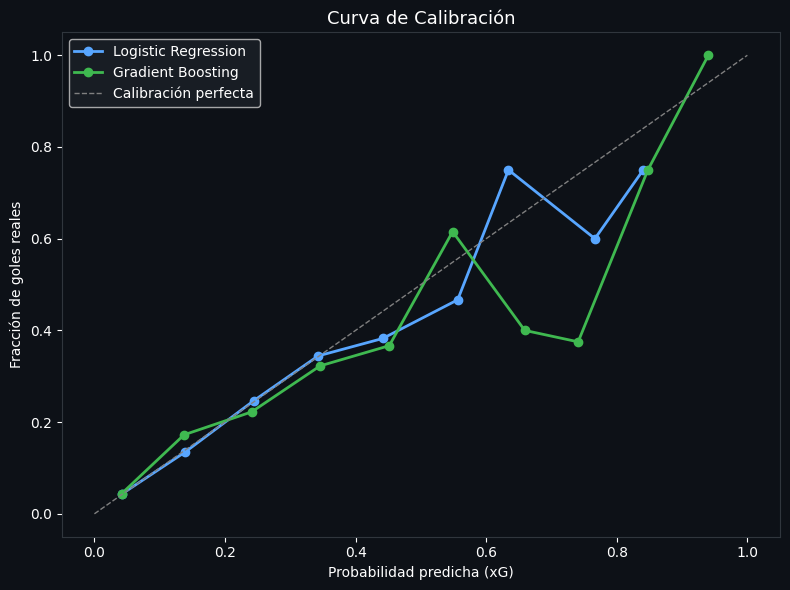

Guardado: p06_03_calibracion.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
ax.set_facecolor(BG)

prob_true_lr, prob_pred_lr = calibration_curve(y_test, lr_probs, n_bins=10)
prob_true_gb, prob_pred_gb = calibration_curve(y_test, gb_probs, n_bins=10)

ax.plot(prob_pred_lr, prob_true_lr, 'o-', color=COLOR,  lw=2, ms=6, label='Logistic Regression')
ax.plot(prob_pred_gb, prob_true_gb, 'o-', color=GREEN,  lw=2, ms=6, label='Gradient Boosting')
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Calibración perfecta')

ax.set_xlabel('Probabilidad predicha (xG)', color='white')
ax.set_ylabel('Fracción de goles reales', color='white')
ax.set_title('Curva de Calibración', color='white', fontsize=13)
ax.legend(facecolor='#1c2128', labelcolor='white', framealpha=0.8)
ax.tick_params(colors='white')
ax.spines[:].set_color('#30363d')

plt.tight_layout()
plt.savefig('graficos/p06_03_calibracion.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Guardado: p06_03_calibracion.png')

## 7. Importancia de features

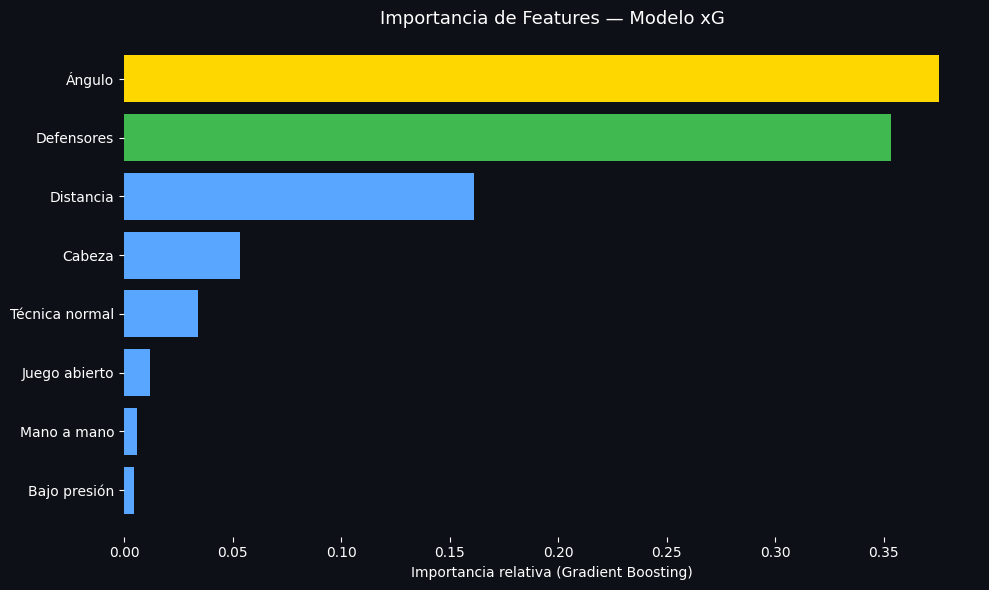

Guardado: p06_04_feature_importance.png


In [10]:
feat_names = ['Distancia', 'Ángulo', 'Cabeza', 'Juego abierto',
              'Bajo presión', 'Mano a mano', 'Técnica normal', 'Defensores']
importances = gb.feature_importances_
order = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(BG)

colors_bar = [GOLD if i == order[-1] else (GREEN if i == order[-2] else COLOR) for i in range(len(feat_names))]
ax.barh(
    [feat_names[i] for i in order],
    importances[order],
    color=[colors_bar[i] for i in order]
)
ax.set_xlabel('Importancia relativa (Gradient Boosting)', color='white')
ax.set_title('Importancia de Features — Modelo xG', color='white', fontsize=13)
ax.tick_params(colors='white')
ax.spines[:].set_visible(False)

plt.tight_layout()
plt.savefig('graficos/p06_04_feature_importance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Guardado: p06_04_feature_importance.png')

## 8. Mapa de xG — todos los tiros del campeonato

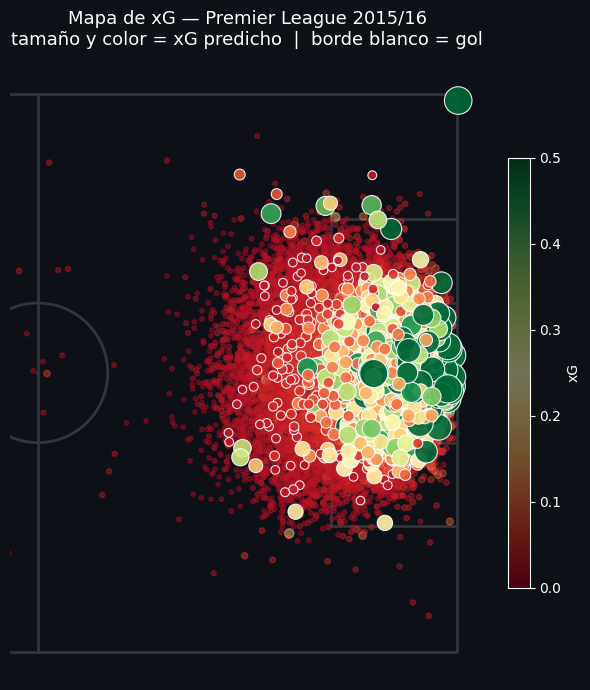

Guardado: p06_05_xg_map.png


In [11]:
# Asignar xG del modelo GB al dataframe completo
shots_clean = shots_df[FEATURES + ['goal', 'x', 'y', 'player', 'team', 'shot_outcome']].dropna(subset=FEATURES).copy()
shots_clean['xg'] = gb.predict_proba(shots_clean[FEATURES].values)[:, 1]

pitch = Pitch(pitch_type='statsbomb', pitch_color=BG, line_color='#30363d', half=True)
fig, ax = pitch.draw(figsize=(12, 7))
fig.patch.set_facecolor(BG)

no_goals = shots_clean[shots_clean['goal'] == 0]
goals    = shots_clean[shots_clean['goal'] == 1]

sc = ax.scatter(no_goals['x'], no_goals['y'],
                c=no_goals['xg'], cmap='RdYlGn', vmin=0, vmax=0.5,
                s=no_goals['xg'] * 200 + 8, alpha=0.45, zorder=3)
ax.scatter(goals['x'], goals['y'],
           c=goals['xg'], cmap='RdYlGn', vmin=0, vmax=0.5,
           s=goals['xg'] * 400 + 30, alpha=0.9, zorder=4,
           edgecolors='white', linewidths=0.8)

cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('xG', color='white', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

ax.set_title('Mapa de xG — Premier League 2015/16\ntamaño y color = xG predicho  |  borde blanco = gol',
             color='white', fontsize=13, pad=15)

plt.tight_layout()
plt.savefig('graficos/p06_05_xg_map.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Guardado: p06_05_xg_map.png')

## 9. Validación por equipo — xG vs Goles reales

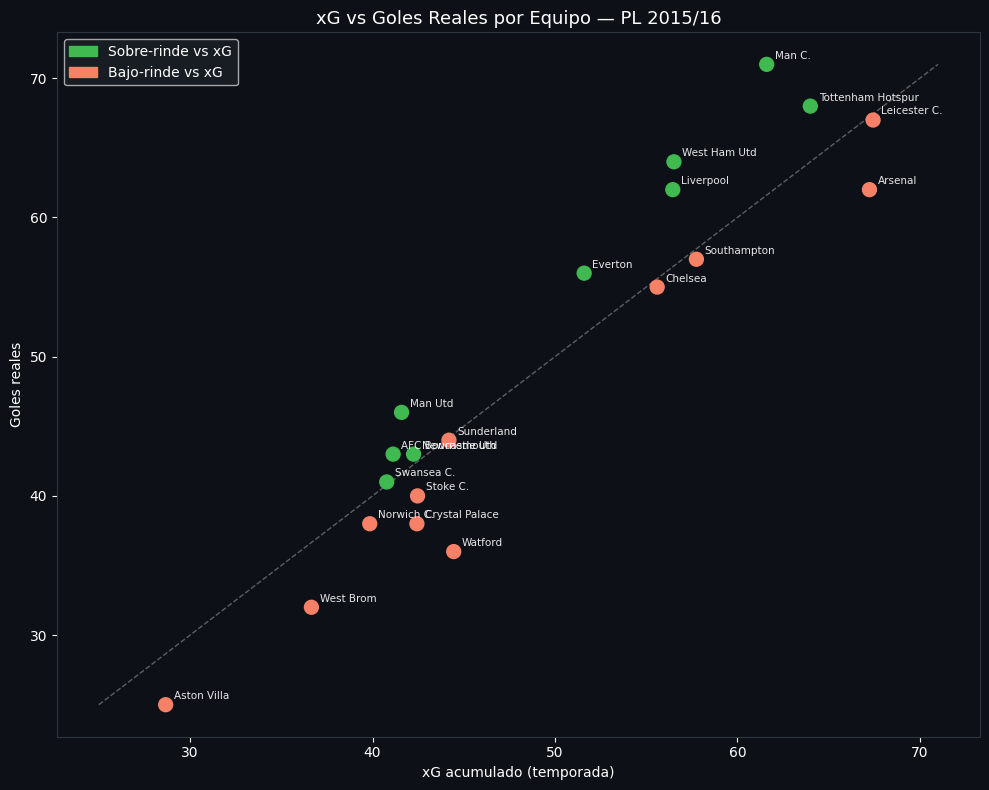

Guardado: p06_06_equipos_xg.png


In [12]:
team_stats = shots_clean.groupby('team').agg(
    xg=('xg', 'sum'),
    goals=('goal', 'sum'),
    shots=('goal', 'count')
).reset_index()
team_stats['diff'] = team_stats['goals'] - team_stats['xg']

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
ax.set_facecolor(BG)

colors_team = [GREEN if d > 0 else ACCENT for d in team_stats['diff']]
ax.scatter(team_stats['xg'], team_stats['goals'], c=colors_team, s=100, zorder=3)

lim = [min(team_stats[['xg','goals']].min()), max(team_stats[['xg','goals']].max())]
ax.plot(lim, lim, '--', color='gray', lw=1, alpha=0.7)

short = {'Manchester': 'Man', ' City': ' C.', ' United': ' Utd',
         'Leicester City': 'Leicester', 'West Bromwich Albion': 'West Brom',
         'Newcastle United': 'Newcastle', 'Swansea City': 'Swansea'}

for _, row in team_stats.iterrows():
    label = row['team']
    for k, v in short.items():
        label = label.replace(k, v)
    ax.annotate(label, (row['xg'], row['goals']),
                textcoords='offset points', xytext=(6, 4),
                fontsize=7.5, color='white', alpha=0.9)

ax.set_xlabel('xG acumulado (temporada)', color='white')
ax.set_ylabel('Goles reales', color='white')
ax.set_title('xG vs Goles Reales por Equipo — PL 2015/16', color='white', fontsize=13)
ax.tick_params(colors='white')
ax.spines[:].set_color('#30363d')

green_patch = mpatches.Patch(color=GREEN, label='Sobre-rinde vs xG')
red_patch   = mpatches.Patch(color=ACCENT, label='Bajo-rinde vs xG')
ax.legend(handles=[green_patch, red_patch], facecolor='#1c2128', labelcolor='white')

plt.tight_layout()
plt.savefig('graficos/p06_06_equipos_xg.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Guardado: p06_06_equipos_xg.png')

## 10. Eficiencia individual — Goles vs xG por jugador

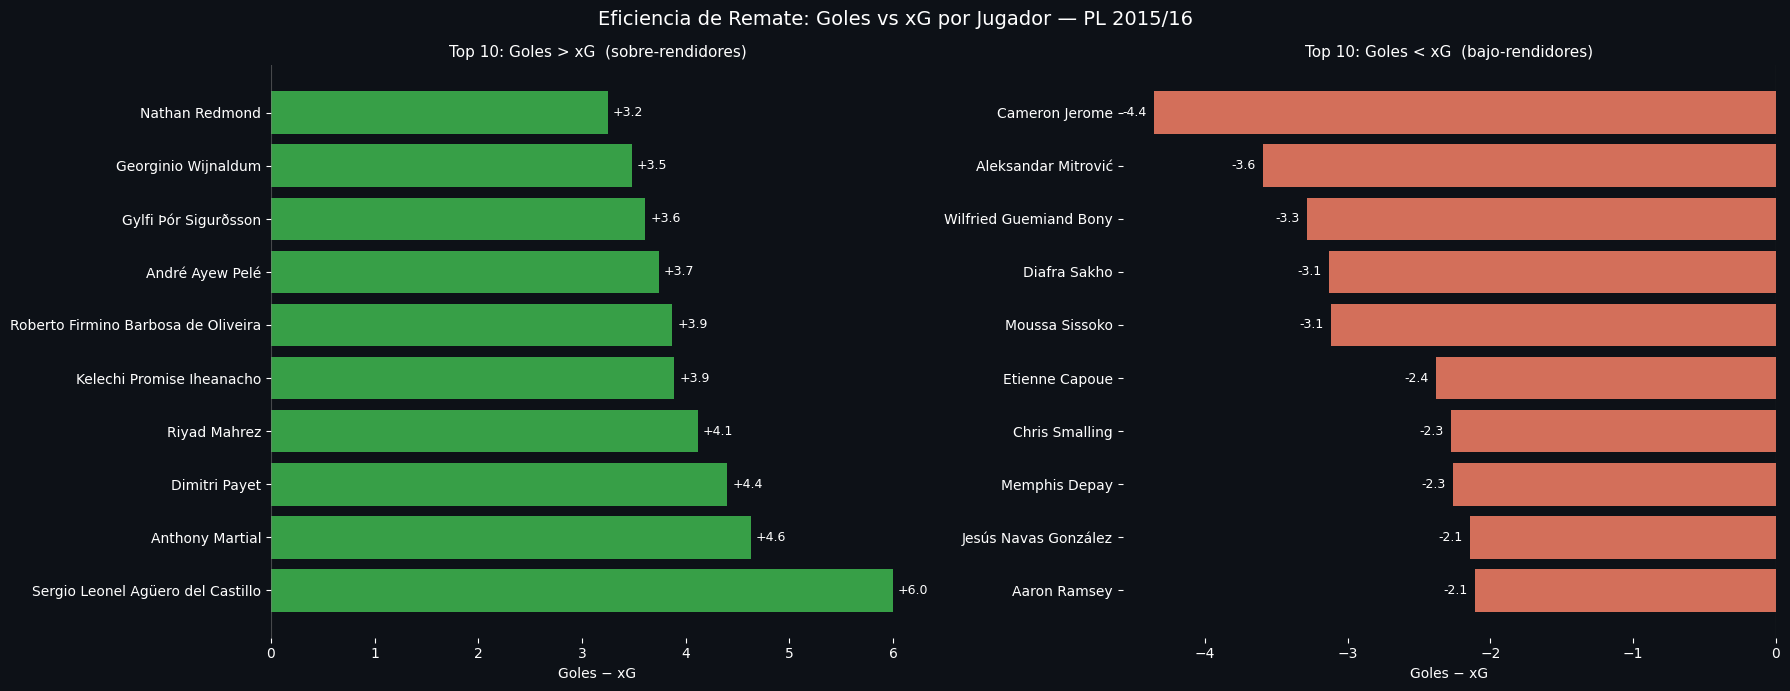

Guardado: p06_07_jugadores_xg.png


In [13]:
player_stats = shots_clean.groupby('player').agg(
    xg=('xg', 'sum'),
    goals=('goal', 'sum'),
    shots=('goal', 'count')
).reset_index()
player_stats['diff'] = player_stats['goals'] - player_stats['xg']
player_stats = player_stats[player_stats['shots'] >= 20]

top_over  = player_stats.nlargest(10, 'diff')
top_under = player_stats.nsmallest(10, 'diff').iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor=BG)

for ax, data, title, color in [
    (axes[0], top_over,  'Top 10: Goles > xG  (sobre-rendidores)', GREEN),
    (axes[1], top_under, 'Top 10: Goles < xG  (bajo-rendidores)',  ACCENT)
]:
    ax.set_facecolor(BG)
    bars = ax.barh(data['player'], data['diff'], color=color, alpha=0.85)
    for bar, val in zip(bars, data['diff']):
        offset = 0.05 if val >= 0 else -0.05
        ha = 'left' if val >= 0 else 'right'
        ax.text(val + offset, bar.get_y() + bar.get_height()/2,
                f'{val:+.1f}', va='center', ha=ha, color='white', fontsize=9)
    ax.set_xlabel('Goles − xG', color='white')
    ax.set_title(title, color='white', fontsize=11)
    ax.tick_params(colors='white')
    ax.spines[:].set_visible(False)
    ax.axvline(0, color='gray', lw=0.8, alpha=0.5)

fig.suptitle('Eficiencia de Remate: Goles vs xG por Jugador — PL 2015/16',
             color='white', fontsize=14)
plt.tight_layout()
plt.savefig('graficos/p06_07_jugadores_xg.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Guardado: p06_07_jugadores_xg.png')

## 11. Resumen del modelo

In [14]:
print('=' * 55)
print('RESUMEN DEL MODELO xG')
print('=' * 55)
print(f'\nDataset: {len(shots_clean):,} tiros  |  {shots_clean["goal"].sum()} goles')
print(f'Tasa de conversión: {shots_clean["goal"].mean()*100:.1f}%')
print(f'\nModelo seleccionado: Gradient Boosting')
print(f'  AUC-ROC:     {roc_auc_score(y_test, gb_probs):.4f}')
print(f'  Log Loss:    {log_loss(y_test, gb_probs):.4f}')
print(f'  Brier Score: {brier_score_loss(y_test, gb_probs):.4f}')
print(f'\nImportancia de features:')
for f, imp in sorted(zip(FEATURES, gb.feature_importances_), key=lambda x: -x[1]):
    print(f'  {f:25s}: {imp:.4f}')
print(f'\nTop 5 por xG acumulado:')
print(player_stats.nlargest(5, 'xg')[['player', 'xg', 'goals', 'shots']].to_string(index=False))

RESUMEN DEL MODELO xG

Dataset: 9,908 tiros  |  988 goles
Tasa de conversión: 10.0%

Modelo seleccionado: Gradient Boosting
  AUC-ROC:     0.7800
  Log Loss:    0.2720
  Brier Score: 0.0774

Importancia de features:
  angle                    : 0.3755
  defenders_freeze         : 0.3532
  distance                 : 0.1614
  is_head                  : 0.0533
  is_normal_technique      : 0.0341
  is_open_play             : 0.0119
  one_on_one               : 0.0058
  under_pressure           : 0.0048

Top 5 por xG acumulado:
                           player        xg  goals  shots
                      Jamie Vardy 23.657990     24    118
                       Harry Kane 22.960337     25    158
             Romelu Lukaku Menama 19.420694     18    116
Sergio Leonel Agüero del Castillo 18.002373     24    118
                Odion Jude Ighalo 17.023269     15    111
